# Test en Machine Learning
## Prétraitement de données

### 1- faites les importations des bibliothèques nécessaires

In [11]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### 2- importer les données du fichier "dataset_ProjetML_2026.csv"

In [12]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### 3- afficher un échontillon du dataframe

In [3]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### 4- afficher toutes les variables du dataset et leurs types respectifs

In [4]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### 5-Afficher le nombre de lignes et de colonnes du dataframe

In [5]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


In [6]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [7]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### 6- Quelles sont les colonnes qui  contiennent des valeurs nulls ? Endéduire le nombre de valeurs nulls

In [9]:
print(df.isna().sum())

Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64


### 7-remplacer les valeurs manquantes dans la colonne "" par la moyenne de la colonne

In [64]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [65]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [66]:
print(df.isna().sum())

Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           514
Source              536
Rapport_Collecte      0
dtype: int64


### Catégorielle

In [67]:
print(df["Categorie"].mode())
print(df["Source"].mode())


0    Plastique
Name: Categorie, dtype: object
0    Collecte_Citoyenne
Name: Source, dtype: object


In [68]:
cat_cols = df.select_dtypes(include=['object']).columns


In [69]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [70]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


### 9- Sachant que la colonne "" est la cible, déduire si le dataset est équilibré ou non?

In [17]:
df["Categorie"].value_counts()

Categorie
Plastique    3309
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [46]:
#OUI la dataset est globalement équilibré car Les classes ne sont pas très éloignées

In [18]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### 11- Chercher les colonnes qui ont des valeurs abbérantes en affichant le boxplot pour tout le dataset

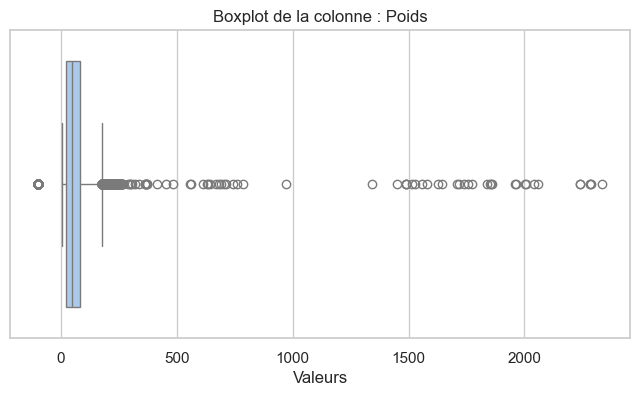

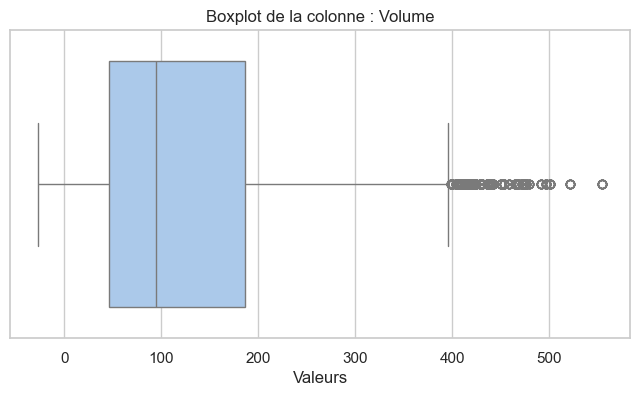

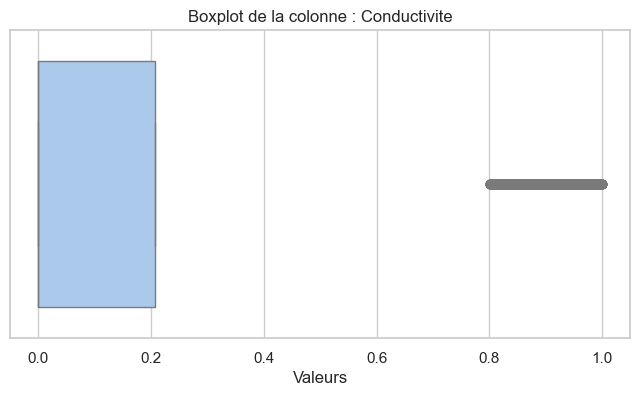

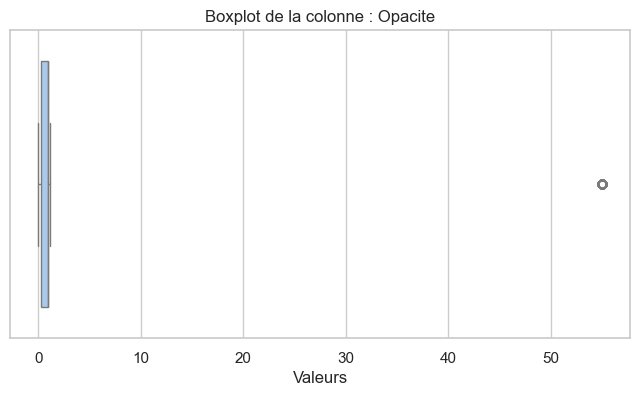

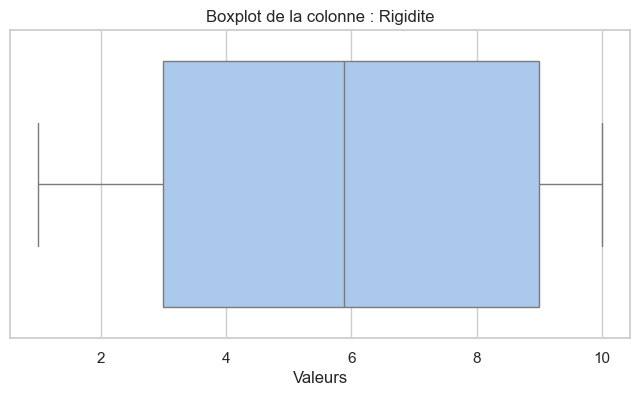

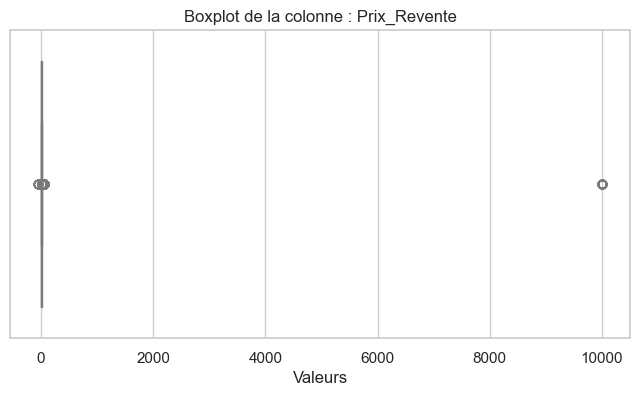

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

In [ ]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


### 12- Nous allons traiter les valeurs abbérantes que la colonne "" en remplaçant ces valeurs par la médiane

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [20]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR


#### b-remplacer les VA par la mediane de la colonne

In [37]:
outliers = df[(df['Poids'] < inf) | (df['Poids'] > sup)]
print(outliers)
for i in df['Poids']:
    if i >=sup or i<=inf:
        df['Poids']=df['Poids'].replace(i,np.median(df['Poids']))

Empty DataFrame
Columns: [Poids, Volume, Conductivite, Opacite, Rigidite, Prix_Revente, Categorie, Source, Rapport_Collecte]
Index: []


#### c-vérifier la modification des VA

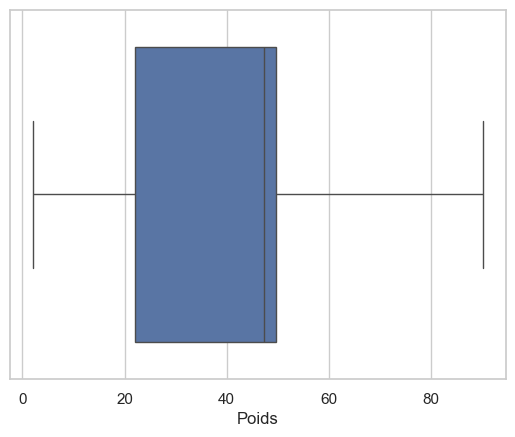

In [39]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

### 13- supprimer les VA de la colonne ''

In [46]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


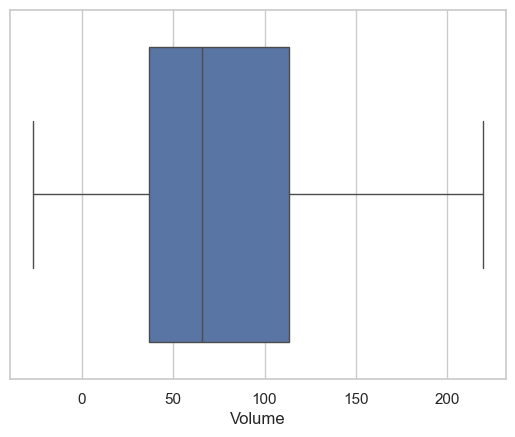

In [47]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

### *13- Traiter les VA de la colonne 

In [48]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


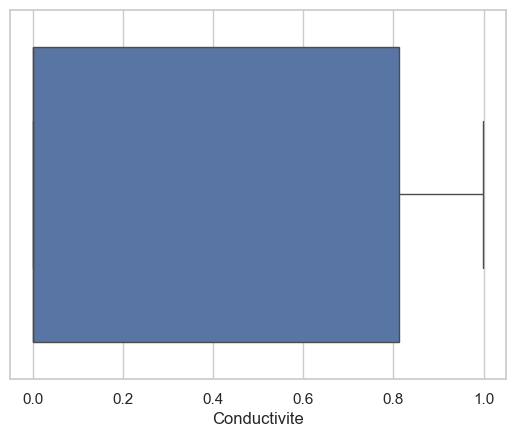

In [49]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

In [54]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


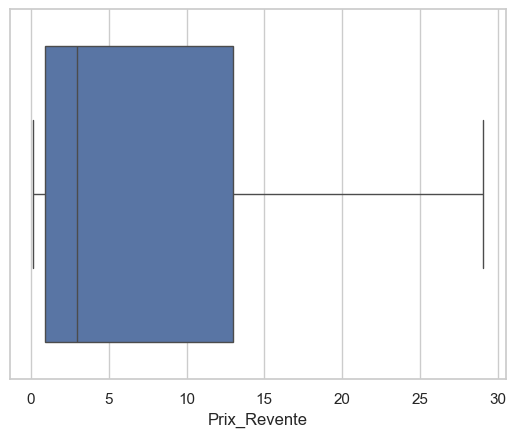

In [55]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

### 14- affecter à Y (cible) la dernière colonne () et le reste du dataframe au entrées X

In [13]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0           Papier
1        Plastique
2            Verre
3           Papier
4           Papier
           ...    
10495        Verre
10496        Verre
10497       Papier
10498    Plastique
10499        Verre
Name: Categorie, Length: 10500, dtype: object

Entrées X :
            Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0       16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1       47.277476   64.702925           0.0       NaN       3.0      4.727748   
2             NaN  317.415183           0.0       NaN       9.0      4.211790   
3             NaN   21.474391           0.0       NaN       1.0      0.442067   
4             NaN   59.462176           0.0  1.000000       NaN      0.723004   
...           ...         ...           ...       ...       ...           ...   
10495  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
10496  149.052713  287.519460           0.0  0.157940      10.0      4.471

### 15- afficher un echontillion de X et Y

In [14]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
6862   37.209809   17.776506      0.968182  1.000000       8.0     11.162943   
5889  193.305052  363.572736      0.000000  0.044535       NaN      5.799152   
6060   16.688013   25.138487           NaN       NaN       2.0      0.834401   
5150    5.693255    5.391739      0.000000  1.000000       2.0      0.284663   
5123   19.122077   35.751878      0.000000       NaN       3.0      0.956104   

          Source  
6862  Centre_Tri  
5889     Usine_A  
6060     Usine_B  
5150     Usine_A  
5123  Centre_Tri  

Echantillon de Y :
694         Métal
4074        Verre
375     Plastique
5169        Métal
3906        Métal
Name: Categorie, dtype: object


### 17- transformer les colonnes catégoriques en numérique

In [15]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

### - Transformer X et Y en tableau numpy

In [17]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)

print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (10500, 11)
Shape de Y : (10500,)


In [23]:
X_class[0:10,:]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 1.67087799e+01, 7.09409765e+01, 0.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 4.72774763e+01, 6.47029253e+01, 0.00000000e+00,
                   nan, 3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00,            nan, 3.17415183e+02, 0.00000000e+00,
                   nan, 9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00,            nan, 2.14743907e+01, 0.00000000e+00,
                   nan, 1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00,            nan, 5.94621756e+01, 0.00000000e+00,
        1.00000000e+00,            nan, 7.23003759e-

### 18- Vérifier cette transformation

In [18]:
Y_class

array([1, 2, 3, ..., 1, 2, 3])

### 19- Subdiviser la dataset en deux parties train et test

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (8400, 11)
x_test: (2100, 11)
y_train: (8400,)
y_test: (2100,)
y_train mean: 1.6923809523809523
y_test mean: 1.6695238095238096


### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


# Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report
import numpy as np

# --- Imputation des NaN (remplacement par la moyenne de chaque colonne) ---
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test  = imputer.transform(x_test)       # transform seulement, pas fit !

# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))

# --- Aperçu des 10 premières prédictions ---
print("\nAperçu des 10 premières prédictions:")
for i in range(10):
    print(f"  [{i}] Vérité: {y_test_eval[i]}  →  Prédiction: {y_pred_knn[i]}")


Confusion Matrix:
 [[466   0   1   0   1]
 [  0 432  10   0   2]
 [  1  14 567   1   6]
 [  0   0   0 504   8]
 [ 16  19  29  23   0]]

Accuracy  : 0.9376
Recall    : 0.7831
Precision : 0.7565

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       468
           1       0.93      0.97      0.95       444
           2       0.93      0.96      0.95       589
           3       0.95      0.98      0.97       512
           4       0.00      0.00      0.00        87

    accuracy                           0.94      2100
   macro avg       0.76      0.78      0.77      2100
weighted avg       0.91      0.94      0.92      2100


Aperçu des 10 premières prédictions:
  [0] Vérité: 4  →  Prédiction: 0
  [1] Vérité: 2  →  Prédiction: 2
  [2] Vérité: 1  →  Prédiction: 1
  [3] Vérité: 3  →  Prédiction: 3
  [4] Vérité: 2  →  Prédiction: 2
  [5] Vérité: 2  →  Prédiction: 2
  [6] Vérité: 3  →  Prédiction: 3
  [7] Vérité: 3 

# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [22]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 5}
Meilleur score     : 0.7857075700249733

Confusion Matrix KNN optimisé:
 [[467   0   1   0   0]
 [  0 434  10   0   0]
 [  1  17 571   0   0]
 [  1   0   0 511   0]
 [ 16  20  28  23   0]]
Accuracy  : 0.9443
Recall    : 0.7886
Precision : 0.7555

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       468
           1       0.92      0.98      0.95       444
           2       0.94      0.97      0.95       589
           3       0.96      1.00      0.98       512
           4       0.00      0.00      0.00        87

    accuracy                           0.94      2100
   macro avg       0.76      0.79      0.77      2100
weighted avg       0.91      0.94      0.92      2100



# Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[465   0   3   0   0]
 [  0 433  11   0   0]
 [  0   9 580   0   0]
 [  0   0   3 507   2]
 [ 16  19  29  23   0]]
Accuracy  : 0.9452
Recall    : 0.7888
Precision : 0.7578

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       468
           1       0.94      0.98      0.96       444
           2       0.93      0.98      0.95       589
           3       0.96      0.99      0.97       512
           4       0.00      0.00      0.00        87

    accuracy                           0.95      2100
   macro avg       0.76      0.79      0.77      2100
weighted avg       0.91      0.95      0.93      2100



## Importance des features

# Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[468   0   0   0   0]
 [  0 442   1   0   1]
 [  0   2 585   0   2]
 [  0   0   0 508   4]
 [ 16  19  29  22   1]]
Accuracy  : 0.9543
Recall    : 0.7985
Precision : 0.7913

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       468
           1       0.95      1.00      0.97       444
           2       0.95      0.99      0.97       589
           3       0.96      0.99      0.98       512
           4       0.12      0.01      0.02        87

    accuracy                           0.95      2100
   macro avg       0.79      0.80      0.79      2100
weighted avg       0.92      0.95      0.94      2100



In [42]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 1.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]



les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(classification_report(y_test, y_predictSVM_l))

[[464   0   3   0   1]
 [  0 371  73   0   0]
 [  1  80 508   0   0]
 [  4   0   0 507   1]
 [ 17  22  25  23   0]]
Accuracy linear SVM 0.881
Precision linear SVM 0.706
Recall linear SVM 0.736
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       468
           1       0.78      0.84      0.81       444
           2       0.83      0.86      0.85       589
           3       0.96      0.99      0.97       512
           4       0.00      0.00      0.00        87

    accuracy                           0.88      2100
   macro avg       0.71      0.74      0.72      2100
weighted avg       0.85      0.88      0.86      2100



# Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [27]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))

[[456   0   8   0   4]
 [  0 370  74   0   0]
 [  0  75 512   0   2]
 [  2   0   2 507   1]
 [ 16  21  27  23   0]]
Accuracy Logistic Regression 0.879
Precision Logistic Regression 0.707
Recall Logistic Regression 0.733


# Sommary

In [29]:
print("| Algorithm         | Accuracy   | Recall     | Precision  |")
print("| ----------------- | ---------- | ---------- | ---------- |")
print("| Optimized kNN     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(knn_op_acc, knn_op_rec, knn_op_prec))
print("| Decision Tree     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(accur_dt, rec_dt, pres_dt))
print("| Random Forest     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(rf_acc, rf_rec, rf_prec))
print("| Linear SVM        | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(svm_acc, svm_rec, svm_prec))
print("| Logistic Reg      | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(LR_acc, LR_rec, LR_prec))

| Algorithm         | Accuracy   | Recall     | Precision  |
| ----------------- | ---------- | ---------- | ---------- |
| Optimized kNN     | 0.944    | 0.789    | 0.755    |
| Decision Tree     | 0.945    | 0.789    | 0.758    |
| Random Forest     | 0.954    | 0.798    | 0.791    |
| Linear SVM        | 0.881    | 0.736    | 0.706    |
| Logistic Reg      | 0.879    | 0.733    | 0.707    |
